In [ ]:
# Person 2 — Descriptive Statistics

## Part C — Describe What You Have

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("cleaned_data.xlsx")

In [3]:
df.head()

,student_id,branch,track,gender,age,study_hours_week,commute_minutes,sleep_hours,projects_submitted,satisfaction_1to5,has_laptop,transport,pets_at_home,favorite_sport,final_score
0,ITI-1031,Cairo,Data Science,Male,21.0,16.5,34.1,5.5,2,3.0,Yes,Car,0.0,Swimming,79.3
1,ITI-1117,Assiut,Data Science,Female,29.0,25.1,5.0,6.6,3,4.0,Yes,Metro,1.0,Football,91.7
2,ITI-1080,Cairo,Data Science,Male,25.0,14.1,73.2,7.7,0,4.0,Yes,Bus,0.0,NaN,79.3
3,ITI-1128,Cairo,Web Development,Female,25.0,NaN,13.7,6.3,2,4.0,Yes,Metro,1.0,NaN,90.6
4,ITI-1197,Menoufia,Web Development,Male,25.0,19.9,17.2,6.9,3,3.0,No,Car,0.0,NaN,86.8


In [4]:
df.shape

(265, 15)

In [5]:
df.columns

Index(['student_id', 'branch', 'track', 'gender', 'age', 'study_hours_week',
       'commute_minutes', 'sleep_hours', 'projects_submitted',
       'satisfaction_1to5', 'has_laptop', 'transport', 'pets_at_home',
       'favorite_sport', 'final_score'],
      dtype='object')

In [6]:
df["commute_minutes"].dtype

dtype('float64')

In [7]:
df["commute_minutes"].isna().sum()

np.int64(6)

In [8]:
print("Total rows:", len(df))
print("Valid commute values:", df["commute_minutes"].count())
print("Missing commute values:", df["commute_minutes"].isna().sum())

Total rows: 265
Valid commute values: 259
Missing commute values: 6


In [9]:
df["commute_minutes"].describe()

count    259.000000
mean      45.087645
std       39.301972
min        5.000000
25%       20.550000
50%       33.000000
75%       58.300000
max      256.500000
Name: commute_minutes, dtype: float64

In [ ]:
## mean = Sum of all commute times / Number of valid commute observations
mean_commute = df["commute_minutes"].mean()

print("Mean commute time:", mean_commute)

Mean commute time: 45.08764478764479


In [ ]:
## the middle value after ranking the data
median_commute = df["commute_minutes"].median()
print("median commute time", median_commute)

median commute time 33.0


In [12]:
mode_commute = df["commute_minutes"].mode()

print("Mode:")
print(mode_commute)

Mode:
0    11.8
1    16.1
2    25.9
3    37.2
4    64.1
Name: commute_minutes, dtype: float64


In [ ]:
#The data has multiple modes: 11.8, 16.1, 25.9, 37.2, and 64.1 minutes, indicating that no single commute time occurs more frequently than the others.

In [13]:
## Range=Maximum−Minimum

minimum_commute = df["commute_minutes"].min()
maximum_commute = df["commute_minutes"].max()

range_commute = maximum_commute - minimum_commute

print("Minimum:", minimum_commute)
print("Maximum:", maximum_commute)
print("Range:", range_commute)

Minimum: 5.0
Maximum: 256.5
Range: 251.5


In [16]:
## The value of data dispersion

std_commute = df["commute_minutes"].std()

print("Standard Deviation:", std_commute)

Standard Deviation: 39.30197247665193


In [17]:
q1 = df["commute_minutes"].quantile(0.25)

print("Q1:", q1)

Q1: 20.549999999999997


In [18]:
q3 = df["commute_minutes"].quantile(0.75)

print("Q3:", q3)

Q3: 58.3


In [19]:
iqr = q3 - q1

print("IQR:", iqr)

IQR: 37.75


In [20]:
statistics_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Value": [
        mean_commute,
        median_commute,
        ", ".join(map(str, mode_commute.tolist())),
        minimum_commute,
        maximum_commute,
        range_commute,
        std_commute,
        q1,
        q3,
        iqr
    ]
})

statistics_summary

,Statistic,Value
0,Mean,45.087645
1,Median,33.0
2,Mode,"11.8, 16.1, 25.9, 37.2, 64.1"
3,Minimum,5.0
4,Maximum,256.5
5,Range,251.5
6,Standard Deviation,39.301972
7,Q1,20.55
8,Q3,58.3
9,IQR,37.75


In [ ]:
### Interpretation of Descriptive Statistics

# /*The descriptive statistics were calculated using the cleaned survey data.
# Missing values in `commute_minutes` were excluded from each calculation without deleting the corresponding student records.

# The mean commute time is 45.09 minutes, while the median is 33 minutes.
# The difference between the mean and median suggests that the distribution may be right-skewed, with some relatively long commute times pulling the mean upward.

# The minimum commute time is 5 minutes and the maximum is 256.5 minutes, giving a range of 251.5 minutes.

# The standard deviation is 39.30 minutes, indicating considerable variability in commute times.

# Q1 is 20.55 minutes and Q3 is 58.30 minutes, so the IQR is 37.75 minutes. This means that the middle 50% of valid commute times lies between 20.55 and 58.30 minutes.

In [ ]:
### Expected Distribution Shape

##Because the mean commute time (45.09 minutes) is considerably higher than the median (33 minutes), we expect the distribution to be right-skewed. This is only a prediction and will be checked using a histogram.

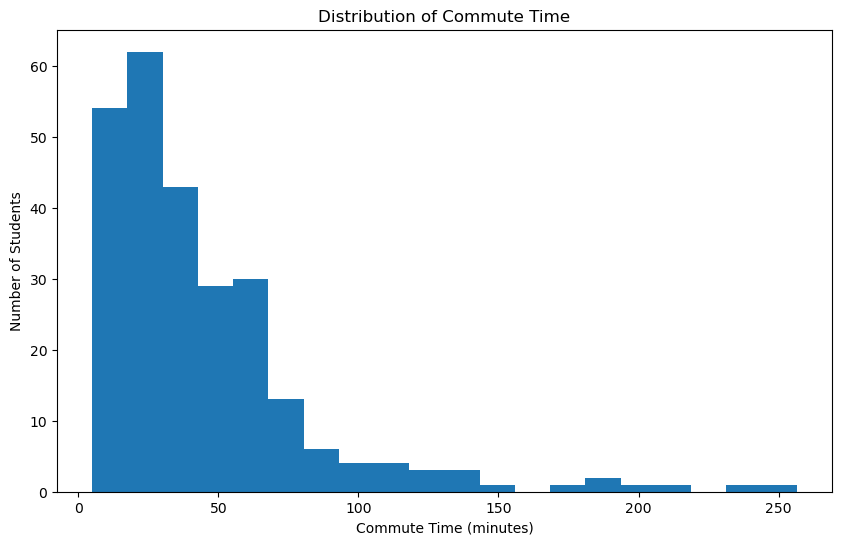

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["commute_minutes"].dropna(), bins=20)

plt.title("Distribution of Commute Time")
plt.xlabel("Commute Time (minutes)")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
### Histogram Interpretation

# The histogram shows that most commute times are concentrated at relatively lower values, while a smaller number of students have much longer commute times.

# The distribution is therefore right-skewed, which supports our initial prediction based on the mean being higher than the median.

# The long right tail is consistent with the presence of some unusually long commute times, including the maximum value of 256.5 minutes.


In [ ]:
### Typical Commute

# If one measure had to be reported as the typical commute time, the median would be the most appropriate measure.

# The median commute time is 33 minutes. Since the distribution is right-skewed, the mean of 45.09 minutes is influenced upward by students with unusually long commute times.

# Therefore, the median provides a more representative description of the typical student's commute time, while the mean can still be reported as a useful measure of the overall average.


In [ ]:
## C3

### SD vs IQR

# The standard deviation is 39.30 minutes, indicating considerable variability around the mean commute time.

# The IQR is 37.75 minutes, meaning that the middle 50% of valid commute times fall between 20.55 and 58.30 minutes.

# Because the distribution is right-skewed and contains some very long commute times, the standard deviation is more affected by extreme values, while the IQR provides a more robust measure of the spread of the central part of the data.


In [22]:
## CV

cv_commute = (std_commute / mean_commute) * 100

print(f"CV for Commute Time: {cv_commute:.2f}%")

CV for Commute Time: 87.17%


In [23]:
mean_score = df["final_score"].mean()
std_score = df["final_score"].std()

cv_score = (std_score / mean_score) * 100

print(f"Mean Final Score: {mean_score:.2f}")
print(f"SD Final Score: {std_score:.2f}")
print(f"CV for Final Score: {cv_score:.2f}%")

Mean Final Score: 79.50
SD Final Score: 9.78
CV for Final Score: 12.30%


In [ ]:
### Comparing Relative Variability

# The coefficient of variation for commute time is 87.16%, while the coefficient of variation for final score is 12.30%.

# The commute time therefore has much greater relative variability compared with the final score. This indicates that students' commute times differ considerably relative to their average commute time, whereas final scores are more consistent relative to their average score.

# The coefficient of variation is appropriate for this comparison because commute time and final score are measured on different scales.


In [24]:
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"Lower Fence: {lower_fence:.2f}")
print(f"Upper Fence: {upper_fence:.2f}")

Lower Fence: -36.08
Upper Fence: 114.92


In [26]:
outliers = df[
    (df["commute_minutes"] < lower_fence) |
    (df["commute_minutes"] > upper_fence)
]

print(f"Number of Outliers: {len(outliers)}")


outliers[["commute_minutes"]].sort_values("commute_minutes")

Number of Outliers: 15


,commute_minutes
45,116.1
73,120.2
196,121.4
152,126.7
123,132.0
43,133.7
241,142.3
147,154.0
99,176.0
163,190.2


In [ ]:
### STEP 20 — Outliers Using the 1.5 × IQR Rule

# The commute time data has an IQR of 37.75 minutes.

# Using the 1.5 × IQR rule:

# * Lower Fence = -36.08 minutes
# * Upper Fence = 114.92 minutes

# Any commute time above 114.92 minutes is considered an outlier.

# There are 15 outliers in the commute time data. Their values range from 116.1 minutes to 256.5 minutes.

# These unusually long commute times contribute to the right-skewed distribution and can increase the mean commute time. This helps explain why the mean (45.09 minutes) is considerably higher than the median (33 minutes).


In [27]:
print(df["branch"].nunique())

5


In [29]:
branch_summary = df.groupby("branch")["commute_minutes"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    SD="std"
)

branch_summary

,Count,Mean,Median,SD
branch,,,,
Alexandria,53,44.281132,34.8,37.100208
Assiut,31,25.451613,24.0,16.057187
Cairo,99,59.972727,46.4,44.801416
Mansoura,42,32.259524,27.7,30.063973
Menoufia,34,36.752941,29.2,35.782891


In [30]:
overall_mean = df["commute_minutes"].mean()

branch_summary["Above_Overall_Mean"] = (
    branch_summary["Mean"] > overall_mean
)

print(branch_summary)

            Count       Mean  Median         SD  Above_Overall_Mean
branch                                                             
Alexandria     53  44.281132    34.8  37.100208               False
Assiut         31  25.451613    24.0  16.057187               False
Cairo          99  59.972727    46.4  44.801416                True
Mansoura       42  32.259524    27.7  30.063973               False
Menoufia       34  36.752941    29.2  35.782891               False


In [ ]:
### STEP 22 — Branch Influencing the Overall Mean

# The overall mean commute time is 45.09 minutes.

# Among the five branches, Cairo has the highest mean commute time at 59.97 minutes. This is above the overall mean, while the mean commute times of Alexandria, Assiut, Mansoura, and Menoufia are below the overall mean.

# Therefore, Cairo contributes to increasing the overall mean commute time.


In [31]:
df_without_cairo = df[df["branch"] != "Cairo"]

mean_without_cairo = df_without_cairo["commute_minutes"].mean()

print(f"Overall Mean: {overall_mean:.2f}")
print(f"Mean Without Cairo: {mean_without_cairo:.2f}")

Overall Mean: 45.09
Mean Without Cairo: 35.88


In [32]:
### STEP 23 — Effect of Removing Cairo

# The overall mean commute time for all students is 45.09 minutes.

# After removing students from the Cairo branch, the mean commute time decreases to 35.88 minutes.

#This is a decrease of 9.21 minutes. The result confirms that the Cairo branch has a noticeable influence on the overall mean because its average commute time (59.97 minutes) is higher than the overall average.


In [34]:
sd_comparison = branch_summary[["SD"]].sort_values("SD", ascending=False)

sd_comparison

,SD
branch,
Cairo,44.801416
Alexandria,37.100208
Menoufia,35.782891
Mansoura,30.063973
Assiut,16.057187


In [35]:
smallest_sd_branch = branch_summary["SD"].idxmin()
smallest_sd = branch_summary["SD"].min()

print(f"Branch with Smallest SD: {smallest_sd_branch}")
print(f"Smallest SD: {smallest_sd:.2f} minutes")

Branch with Smallest SD: Assiut
Smallest SD: 16.06 minutes


In [36]:
### STEP 24 — Branch With the Smallest Standard Deviation

# Assiut has the smallest standard deviation among the five branches, with an SD of 16.06 minutes.

# This indicates that commute times in Assiut are less dispersed around the branch mean compared with the other branches. Therefore, Assiut has the most consistent commute times among the five branches based on standard deviation.
